In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
from meta import ROOT_DIR
from scipy import ndimage as ndi
from bez.data import load_normalized

from skimage import io, data, morphology
from skimage.morphology import dilation, erosion, remove_small_holes, remove_small_objects
from skimage.morphology import disk
from skimage.filters import threshold_otsu, threshold_local, threshold_mean, rank, gaussian, gabor_kernel

# Walkthrough of the pipeline

This project aims to (re-)implement this paper: [Fidelity vs. Simplicity: a Global Approach to Line Drawing Vectorization](https://www-sop.inria.fr/reves/Basilic/2016/FLB16/fidelity_simplicity.pdf)

In this notebook, we will try to give a complete overview of the techniques used and the implementation choices in order to do it.

We strongly advise to read the paper a first time before looking at the notebook. Except for some details, it is well written and have nice illustrations

## Pipeline

Let's start with the central idea: we want to take a photography of a sketch as input, and return a SVG made up of a few curves

![](../images/illustration_butterfly.png)

In order, we
- apply **preprocessing** to translate the image into a black and white mask
- create a **skeleton** and convert it to a graph (chains of pixels)
- use **hypergraph optimization** to find the optimal curves to approximate these chains of pixels

Here is the image we will use for demonstration purposes:

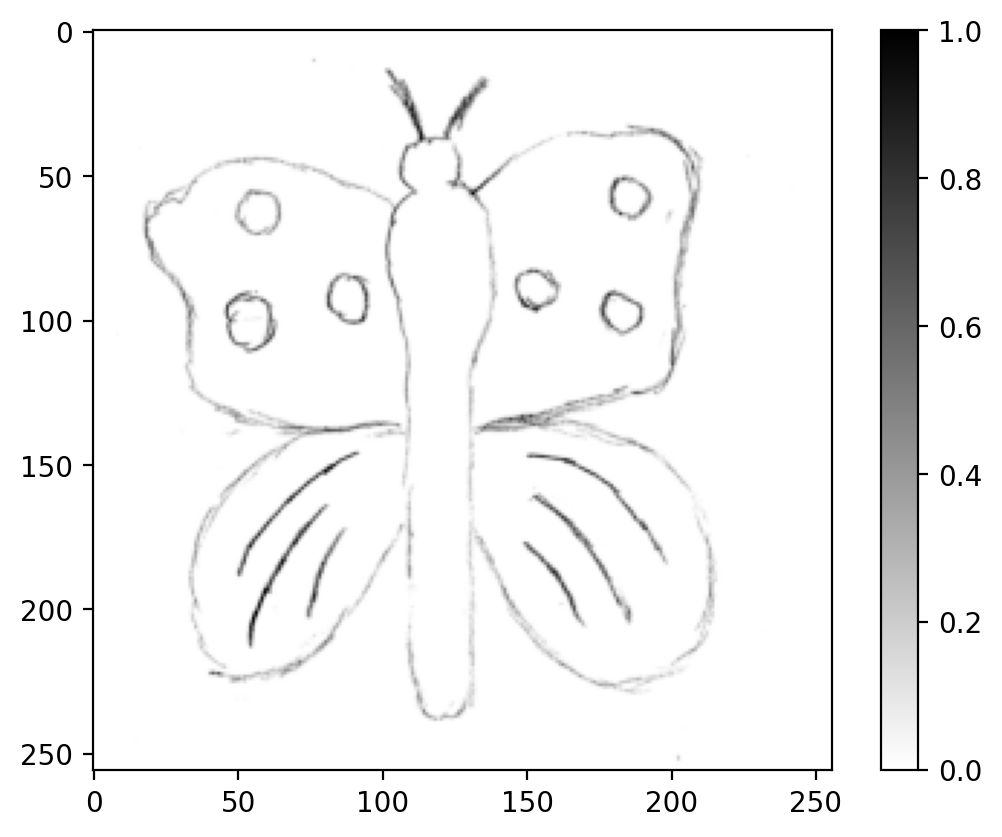

In [ ]:
img = load_normalized(ROOT_DIR / "data/sketches/butterfly.png", d=256)
plt.imshow(img, cmap="binary")
plt.colorbar()
plt.show()

## Preprocessing

Before anything, we need a binary representation of our drawing.

The paper uses advanced trapped-ball and paint-filling techniques, but that would be a lot of work, to be honnest. And not that interesting !

At this point, I was wondering: what if we cloud cheat ? Going from someone's drawing to a logo-like black and white image sounds a lot like a [Style transfer](https://en.wikipedia.org/wiki/Neural_style_transfer):

![](https://s3.amazonaws.com/book.keras.io/img/ch8/style_transfer.png)

We are in 2025 after all, since we don't have a huge brain and a lot of time, maybe we could use a GPU and a lot of data instead ?

So, that's what we did !


Basically, we followed a simple recipe:
1. Get a good quality SVG dataset
2. Convert the SVG to a sketch-like black and white representation
3. Add different kind of noises and texture to simulate drawing on paper
4. Train a CNN to denoise the images.

This was not very hard conceptually, if you're curious you can look at the notebooks "cnn.py" and "svg_dataset.py" in one of these places:
- https://github.com/rambip/sketch-vectorization/tree/main/notebooks/ -> the code
- https://github.com/rambip/sketch-vectorization/tree/main/notebooks/__marimo__ -> the exported notebooks

In [ ]:
_details = mo.as_html(mo.md("""
- the noise must really look like your test images. Otherwise, you're too much out of distribution and the model can't learn properly.
- There is a tradeoff for the resolution: we want a model that can process large images, but it's more costly to train.
- **Don't try a small model**. I thought that a model with an inner dimension of 8 and 4 layers was enough, but it was not the case. Don't fear the overfitting: if you train for long enough and you have diverse enough datapoints, your model will generalize even if it has a lot of parameters. If that seems counter-intuitive to you, go read about [Double Descent](https://en.wikipedia.org/wiki/Double_descent)
- residual connections work really well. We ended up adding them at each layer.

We ended up with: 
- 3000 data points of 256x256
- 8 layers of 3x3 convolutions
- an inner dimension of 32
- SiLU activation function
- 30 epochs, with a batch size of 50
- running on T4 gpus for something like 15min
"""))
mo.md(f"""
<details>
<summary>
In a nutshell, a few lessons we learned:
</summary>
{_details.text}
</details>

But now, let's try it !

We converted it to ONNX format, so it can run without a gpu.
""")

<span class="markdown prose dark:prose-invert contents"><details>
<summary>
In a nutshell, a few lessons we learned:
</summary>
<span class="markdown prose dark:prose-invert contents"><ul>
<li>the noise must really look like your test images. Otherwise, you're too much out of distribution and the model can't learn properly.</li>
<li>There is a tradeoff for the resolution: we want a model that can process large images, but it's more costly to train.</li>
<li><strong>Don't try a small model</strong>. I thought that a model with an inner dimension of 8 and 4 layers was enough, but it was not the case. Don't fear the overfitting: if you train for long enough and you have diverse enough datapoints, your model will generalize even if it has a lot of parameters. If that seems counter-intuitive to you, go read about <a href="https://en.wikipedia.org/wiki/Double_descent" rel="noopener noreferrer" target="_blank">Double Descent</a></li>
<li>residual connections work really well. We ended up adding them at each layer.</li>
</ul>
<span class="paragraph">We ended up with: </span>
<ul>
<li>3000 data points of 256x256</li>
<li>8 layers of 3x3 convolutions</li>
<li>an inner dimension of 32</li>
<li>SiLU activation function</li>
<li>30 epochs, with a batch size of 50</li>
<li>running on T4 gpus for something like 15min</li>
</ul></span>
</details>

<span class="paragraph">But now, let's try it !</span>
<span class="paragraph">We converted it to ONNX format, so it can run without a gpu.</span></span>

In [ ]:
from bez.cnn import load_trained_model

In [ ]:
model = load_trained_model()

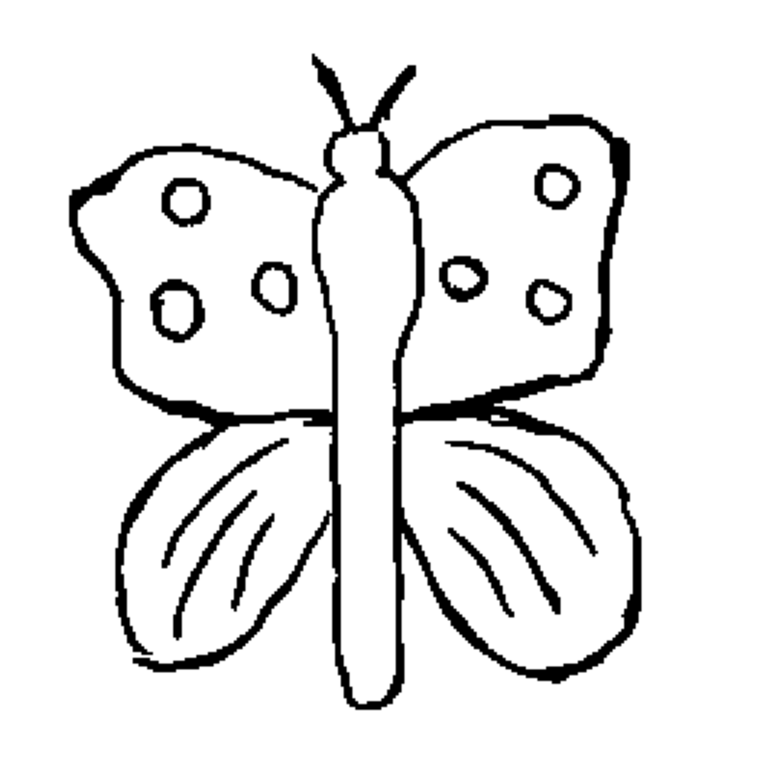

In [ ]:
img_one_channel = img[np.newaxis, :, :]
# we consider it's black if the model
img_binary = model.run(["output"], {"input": img_one_channel})[0][0] > 0.5
plt.imshow(img_binary, cmap="binary")
plt.axis(False)
plt.show()

Since the model is not perfect, there are still a few artefacts in the image.
To remove them, we do a simple 1pixel-dilation.

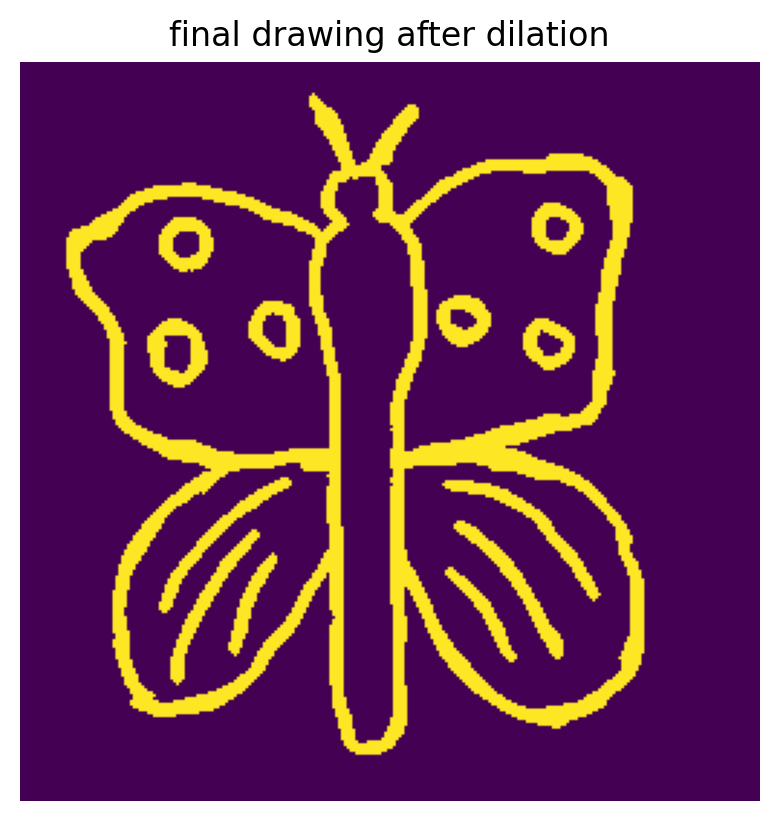

In [ ]:
img_binary_dilated = dilation(img_binary)
plt.imshow(img_binary_dilated)
plt.title("final drawing after dilation")
plt.axis(False)
plt.show()

Next, we compute the thickness of the drawing using erosion:

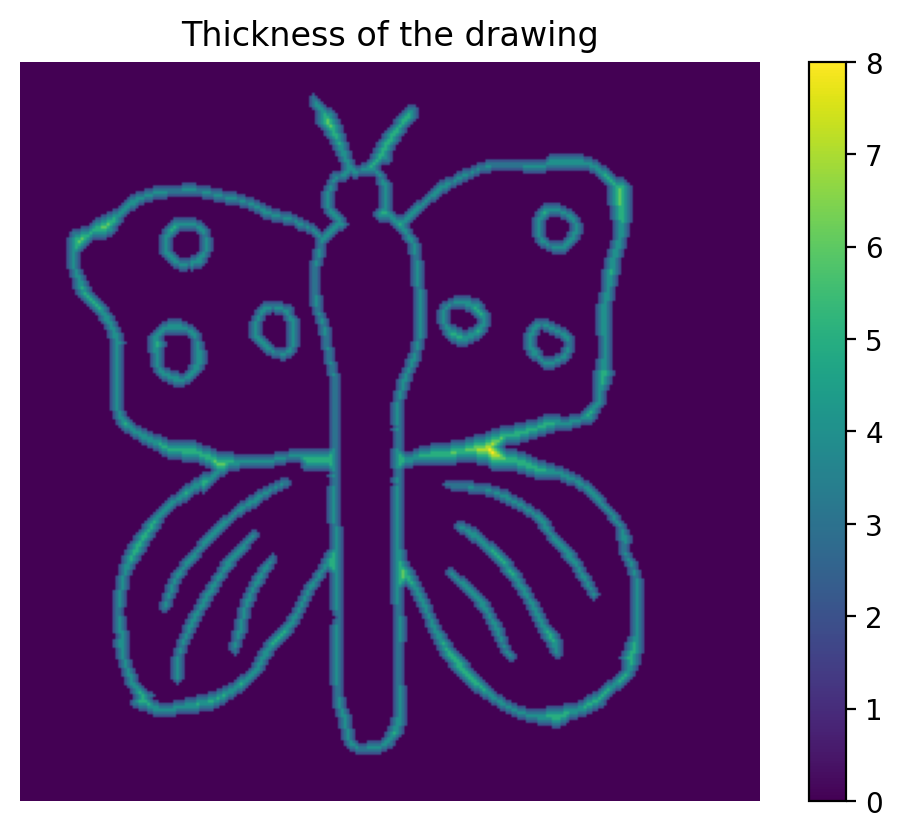

In [ ]:
thicknesses = np.array(img_binary_dilated, dtype=int)
max_line_width_detection = img_binary_dilated.copy()
i = 2
while np.sum(max_line_width_detection) > 0:
    tmp = erosion(max_line_width_detection)
    diff = max_line_width_detection ^ tmp > 0  # iterate the erosion
    thicknesses[diff] = i
    max_line_width_detection = tmp  # find the difference
    i = i + 1
plt.imshow(thicknesses)
plt.axis(False)
plt.colorbar()
plt.title('Thickness of the drawing')
plt.show()

## Skeleton and topological graph

Once we have a nice black and white image, we can create the skeleton very easily using iterative thining.

In [ ]:
from skimage.morphology import skeletonize
import scipy
from bez.topo_graph import extract_simple_topology_from_skeleton, extract_topology_from_skeleton
from bez.viz import visualize_topo

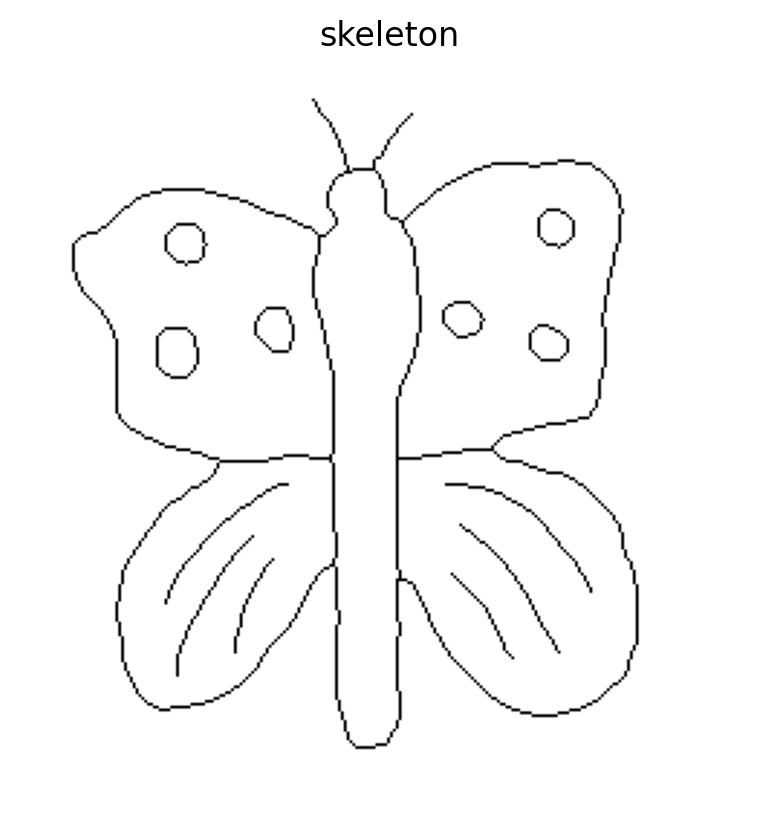

In [ ]:
skeleton = skeletonize(img_binary_dilated, method="zhang")

plt.imshow(1-skeleton, cmap="gray")
plt.title("skeleton")
plt.axis(False)
plt.show()

Once we have this graph, we traverse it in order to get the pixel chains.

This is not explained explicitely in the original paper, but the trick is to look at the **number of neighbours** in the skeleton. Indeed, most nodes in the skeleton have only 3 neighbours. If it is not the case, we call it a "special" pixel

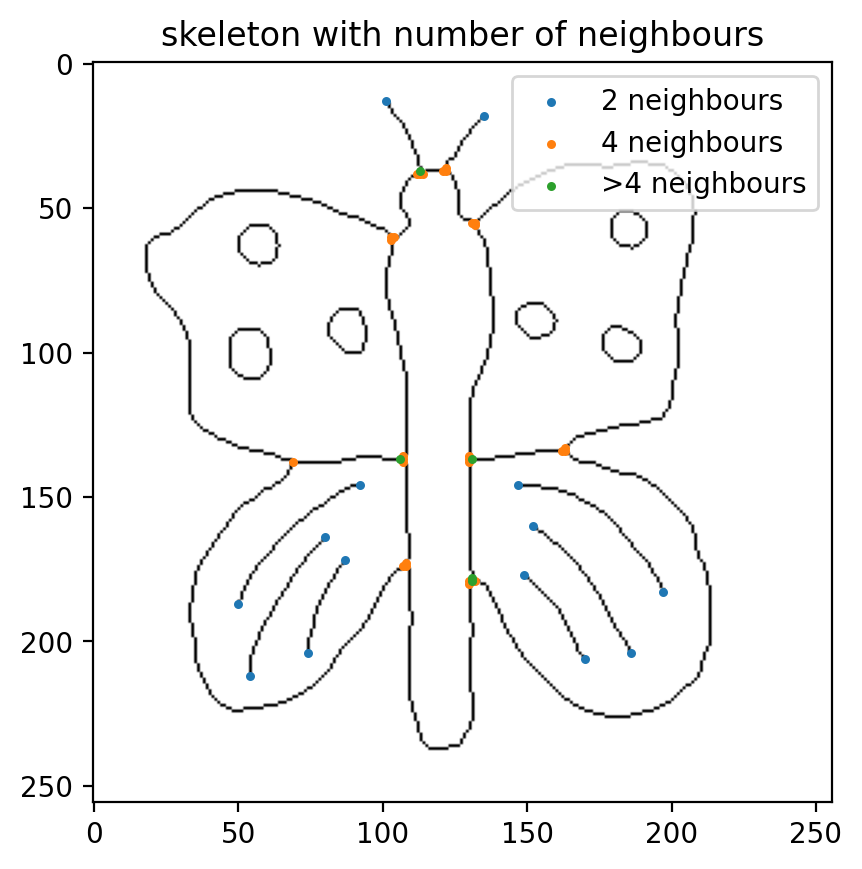

In [ ]:
kernel = np.ones((3, 3), dtype=int)
neighbours = scipy.signal.convolve2d(skeleton.astype(int), kernel, mode="same")
neighbours = neighbours * skeleton
def pos_where(mask):
    return np.where(mask)[1], np.where(mask)[0]

plt.imshow(1 - skeleton, cmap="gray")
plt.scatter(
    *pos_where(neighbours==2),
    label="2 neighbours",
    s=5,
)
plt.scatter(
    *pos_where(neighbours==4),
    label="4 neighbours",
    s=5,
)
plt.scatter(
    *pos_where(neighbours>4),
    label=">4 neighbours",
    s=5,
)
plt.legend()
plt.title("skeleton with number of neighbours")
plt.show()

We use this information to perform a graph traversal, from arbitrary pixels to "special" pixels.
For the special case of loops, we break them into a chain that ends where it starts.

number of nodes: 54


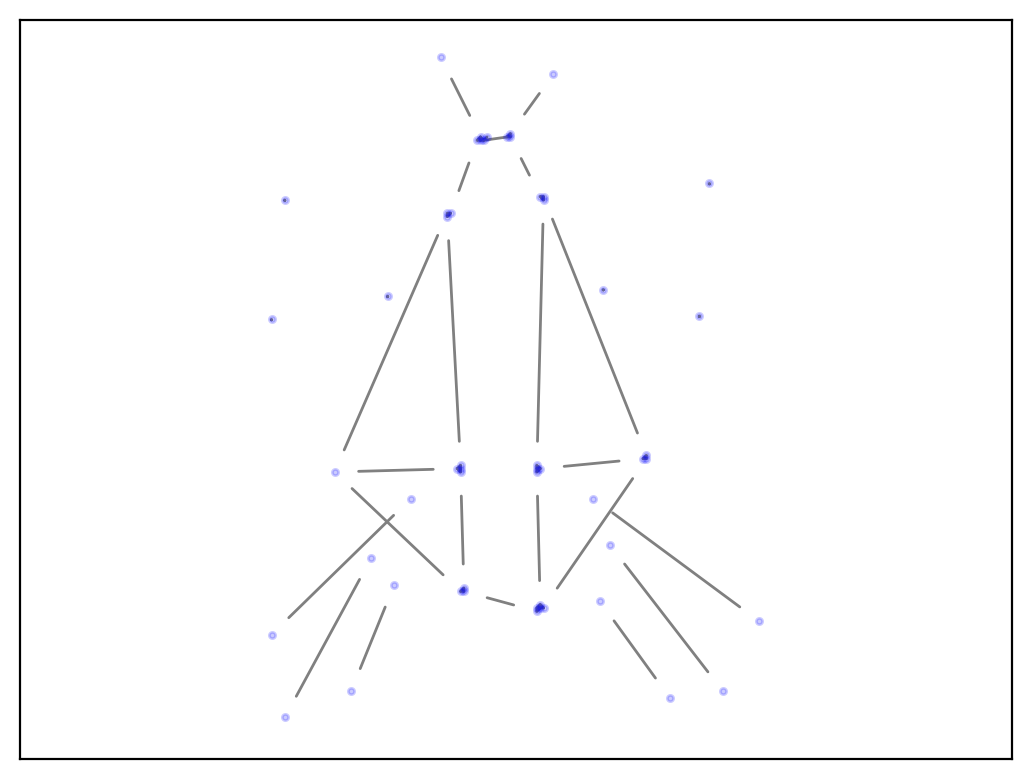

In [ ]:
topo_graph = extract_topology_from_skeleton(skeleton)
visualize_topo(topo_graph, visu_radius=5, opacity=0.2)
print(f"number of nodes: {len(topo_graph.nodes())}")
plt.show()

This graph can be used for the next steps. Unfortunately, we can see that some groups of pixels are clustered together, which will cause a lot of problems.

With a modified algorithm, we are able to merge some of these clusters together.

number of nodes: 30


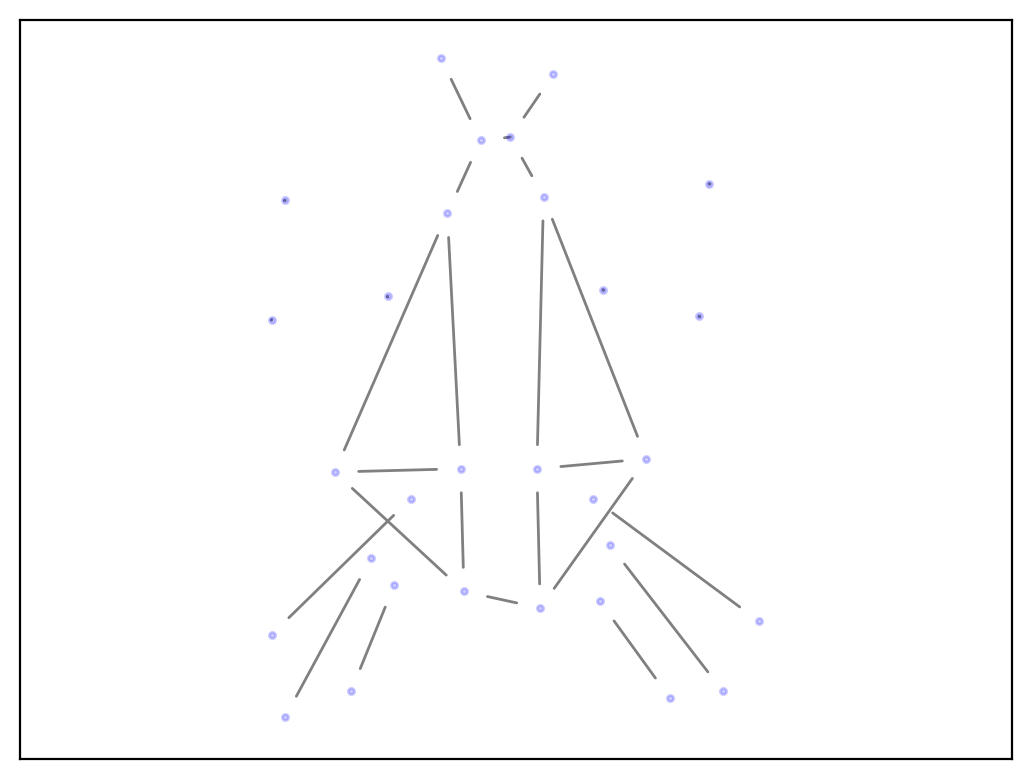

In [ ]:
topo_graph_1 = extract_simple_topology_from_skeleton(skeleton)
visualize_topo(topo_graph_1, visu_radius=5, opacity=0.2)
print(f'number of nodes: {len(topo_graph_1.nodes())}')
plt.show()

## Hyper graph and bezier fiting

Once we have our hypergraph, we can start to use bezier curves to approximate it.
Since it is a simple least square problem, we have derived the closed solution in the form of a linear system to solve.
The code below shows this logic.
Here $q(t)$ is a vector defined as
$$
q(t) = \begin{pmatrix}
(1-t)^3 \\ 3 t (1-t)^2 \\ 2 t^2 (1-t) \\ t^3
\end{pmatrix}
$$

```python
def fit_bezier(traj, t):
    traj_x, traj_y = traj
    m = np.zeros((4, 4))
    bx = np.zeros(4)
    by = np.zeros(4)

    # this equation follows from the minimization of the pixel standard distance
    for i in range(k):
        q = interpolant(t, degree)
        m[i] = np.sum(weights * (q * q[i]), axis=1)
        bx[i] = np.sum(weights * (traj_x * q[i]))
        by[i] = np.sum(weights * (traj_y * q[i]))

    # We use lstsq because the matrix is not always full-rank.
    # For example, if the degree of the bezier is greater than the length of "traj"
    x_fit = np.linalg.lstsq(m, bx)[0]
    y_fit = np.linalg.lstsq(m, by)[0]
    return np.array([x_fit, y_fit])
```

In [ ]:
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.viz import visualize_hyper
from bez.global_optim import optimisation, fit_hyperedge

In [ ]:
hyper = HyperGraph(topo_graph_1)

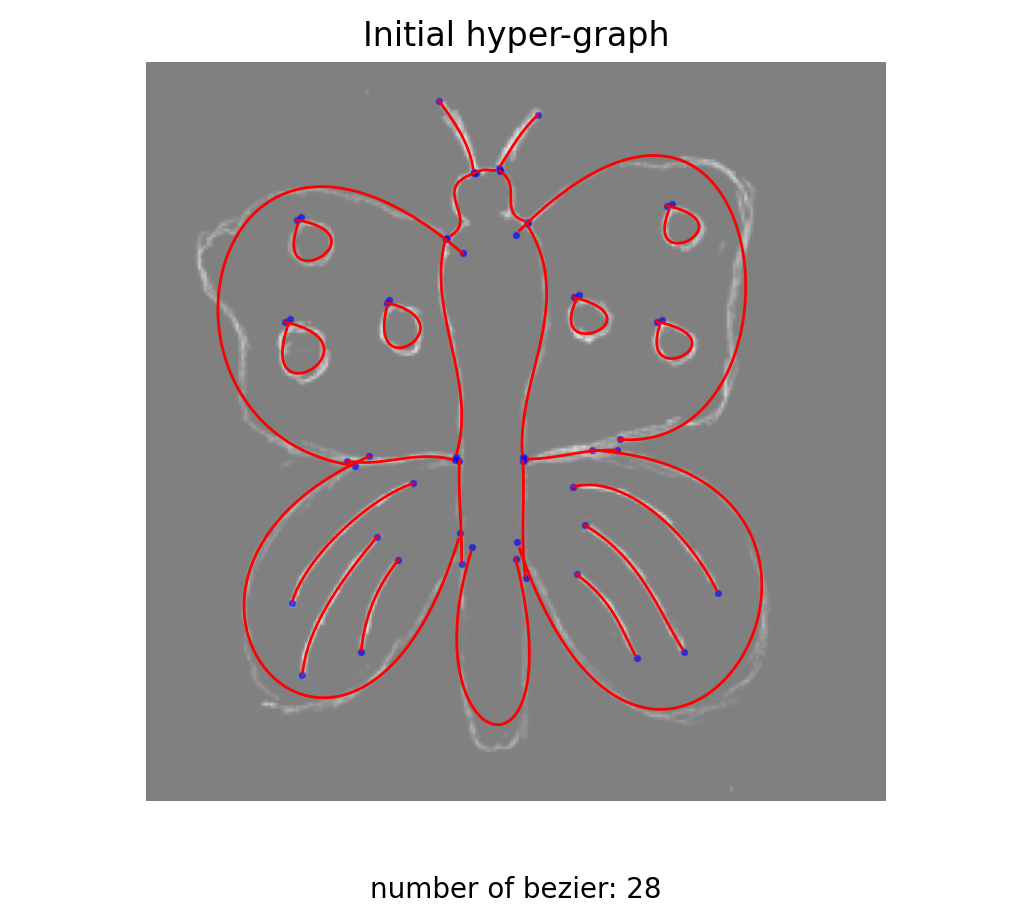

In [ ]:
for _h in hyper.all_hyperedges():
    fit_hyperedge(_h)
visualize_hyper(hyper, offset=0)
plt.imshow(img, alpha=0.5, cmap='gray')
_ax = plt.gca()
_ax.axis('off')
plt.title('Initial hyper-graph')
_ax.text(0.5, -0.1, f'number of bezier: {len(hyper)}', ha='center', va='top', transform=_ax.transAxes)
plt.show()

The main issue with this initial hypergraph is that some curves should be broken down to better fit the image.
We implement the next part of the paper, a dichotomy-based refinement.

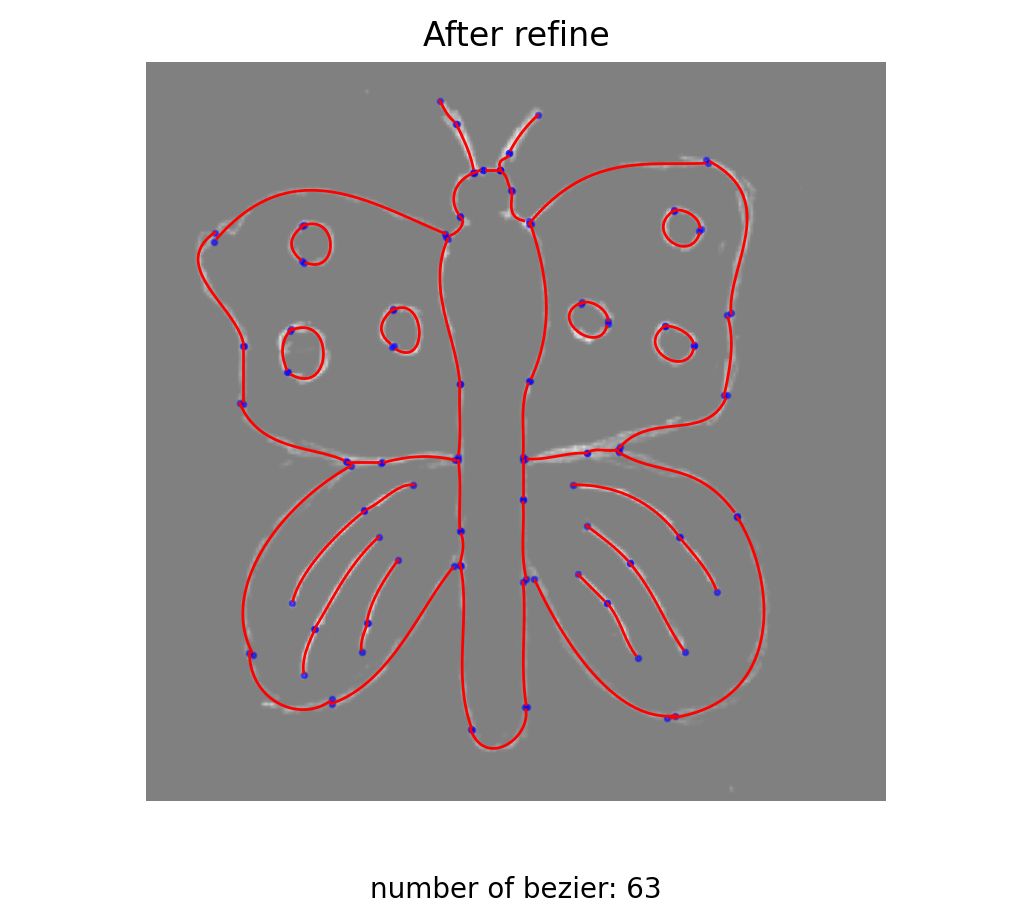

In [ ]:
topo_graph_refine = refine(topo_graph_1, 0.1)
hyper_1 = HyperGraph(topo_graph_refine)
for _h in hyper_1.all_hyperedges():
    fit_hyperedge(_h)
visualize_hyper(hyper_1, offset=0)
plt.imshow(img, alpha=0.5, cmap='gray')
_ax = plt.gca()
_ax.axis('off')
plt.title('After refine')
plt.text(0.5, -0.1, f'number of bezier: {len(hyper_1)}', fontsize=10, ha='center', va='top', transform=_ax.transAxes)
plt.show()

Now, we have to implement what is probably the most difficult part of the paper: the global optimisation.


We will manipulate sequences of edges, that we will call **hyperedges**. The intuition if they are multiple chains of pixels aligned with each other in the topological graph, they should be grouped together to form a longer chain.

This optimisation process is based on the idea of doing **perturbations** on these sequences.

Since the paper is not very explicit about these perturbations, we implemented it in a slightly different (but similar) way.

We first sample pairs of hyperedges $(U, V)$ such that $U$ end at a node that is anywhere inside $V$. We call such a configuation a "T" configuration.

![](../images/schema_t.svg)

Note that hyperedges are oriented. Once we sample one "T", we can apply 6 different transformations:

- increase or decrease the degree of $V$
- splitting V into 2 (if it has more than 3 nodes)
- overlaping V onto U (here, $V$ will become $(y, x, c, d)$)
- dissociating V from U (for that, the last edge of V must be in U)
- merging V and U. This is only possible when the T is in the special configuration showed below:

![](../images/schema_t2.svg)

We add a special transformation: **reverse**. As the name suggests, we reverse the order of all nodes in the sequence.

With the addition of this transformation, this is completely equivalent to the transformations proposed by the paper.


We try to chose the same parameters as the paper each time we can, to be able to compare results.

In [ ]:
lam = 0.2
temp = 0.5
t_min = 0.05
mu = 0.8
t_decrease = 0.99 ** (1 / len(topo_graph_1.nodes))
error = optimisation(hyper_1, lam=lam, mu=mu, temp=temp, t_decrease=t_decrease, t_min=t_min)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6873/6873 [00:04<00:00, 1713.13it/s]


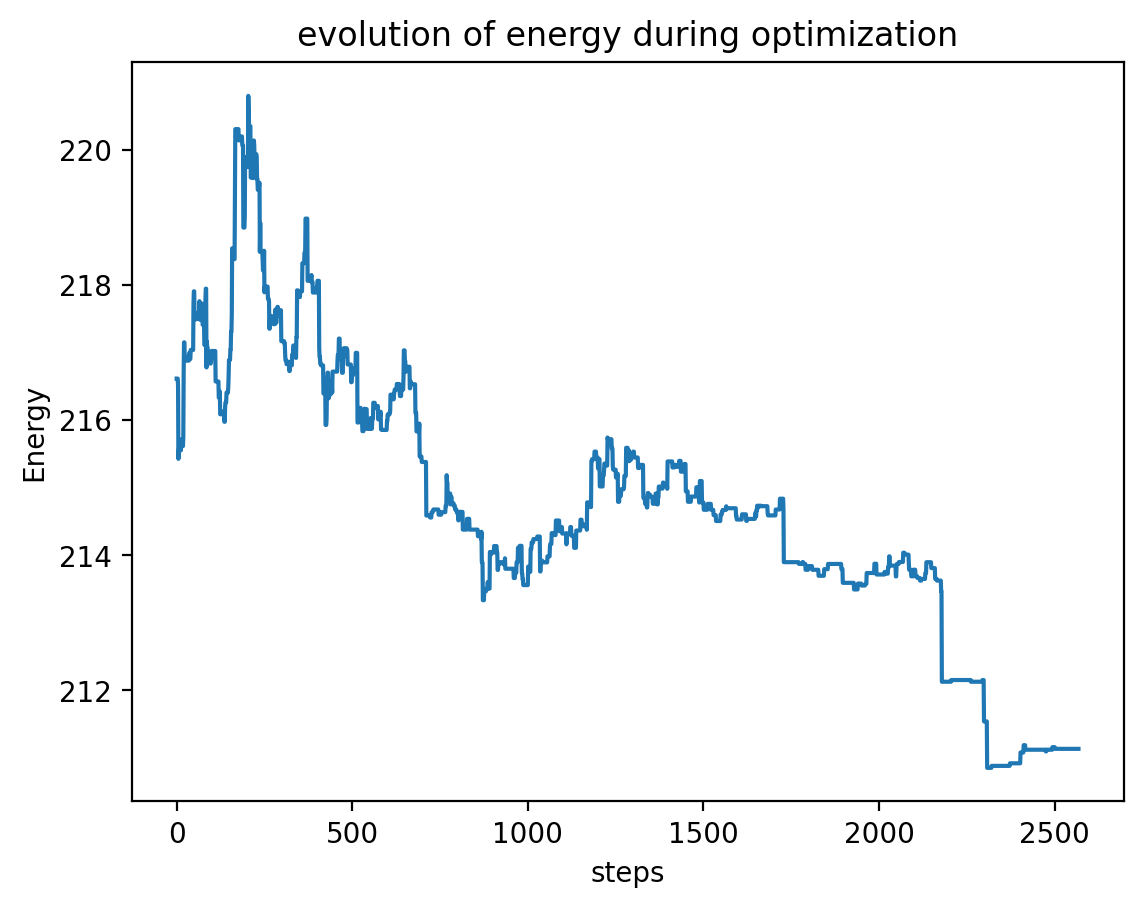

In [ ]:
plt.plot(range(len(error)), error)
plt.ylabel("Energy")
plt.xlabel("steps")
plt.title("evolution of energy during optimization")
plt.show()

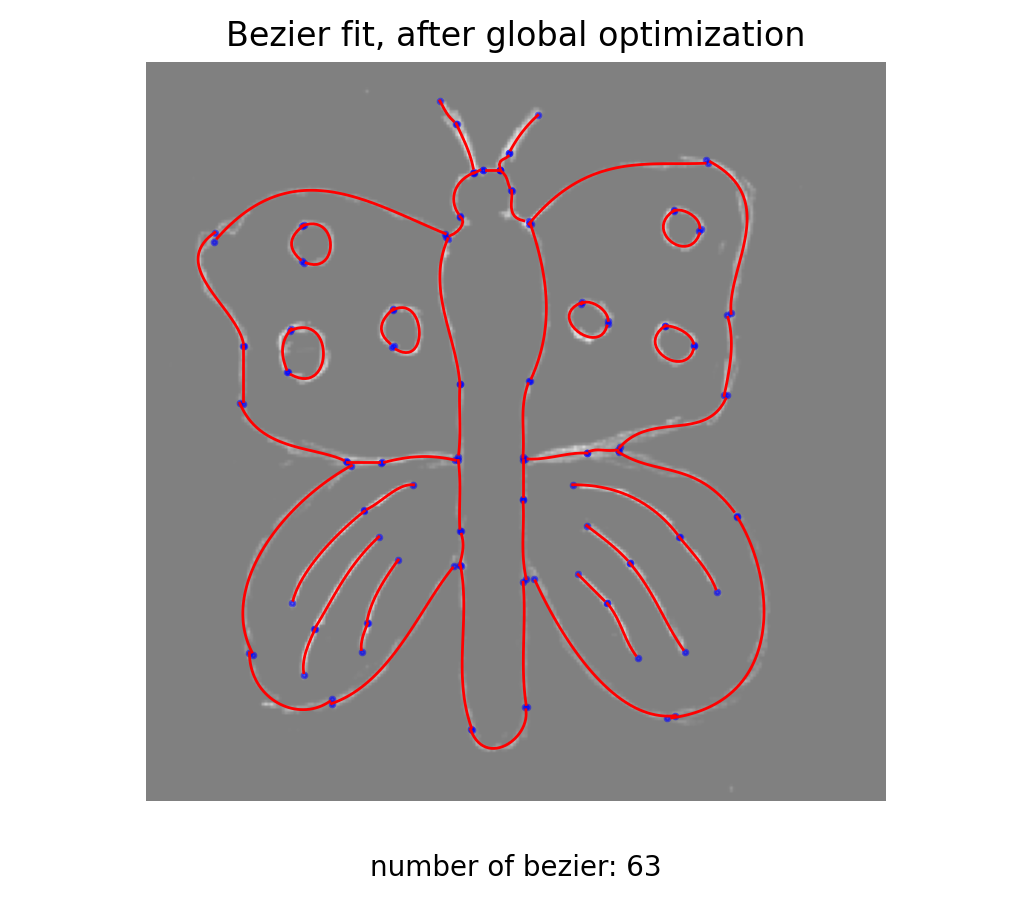

In [ ]:
visualize_hyper(hyper_1)
plt.imshow(img, alpha=0.5, cmap='gray')
_ax = plt.gca()
_ax.axis('off')
plt.title('Bezier fit, after global optimization')
_ax.text(0.5, -0.1, f'number of bezier: {len(hyper_1)}', ha='center', transform=_ax.transAxes)
plt.show()

If we look closely, we see that some lines do not join exactly at the same point. It is logical, since every curve fitting is independent.
The way to fix this problem is specified in the paper, but not exactly.

We chose to implement what seemed like a reasonnable solution.

First for the point-edges junctions, we look again at all our "T" configurations (see above) and force the control point of the incoming curve to fall exactly on the other curve.

For the point-point junctions, we compute the barycenter $B$ of all the points that are supposed to arrive at the same position, and we force the control point of each incoming edge to be $B$.

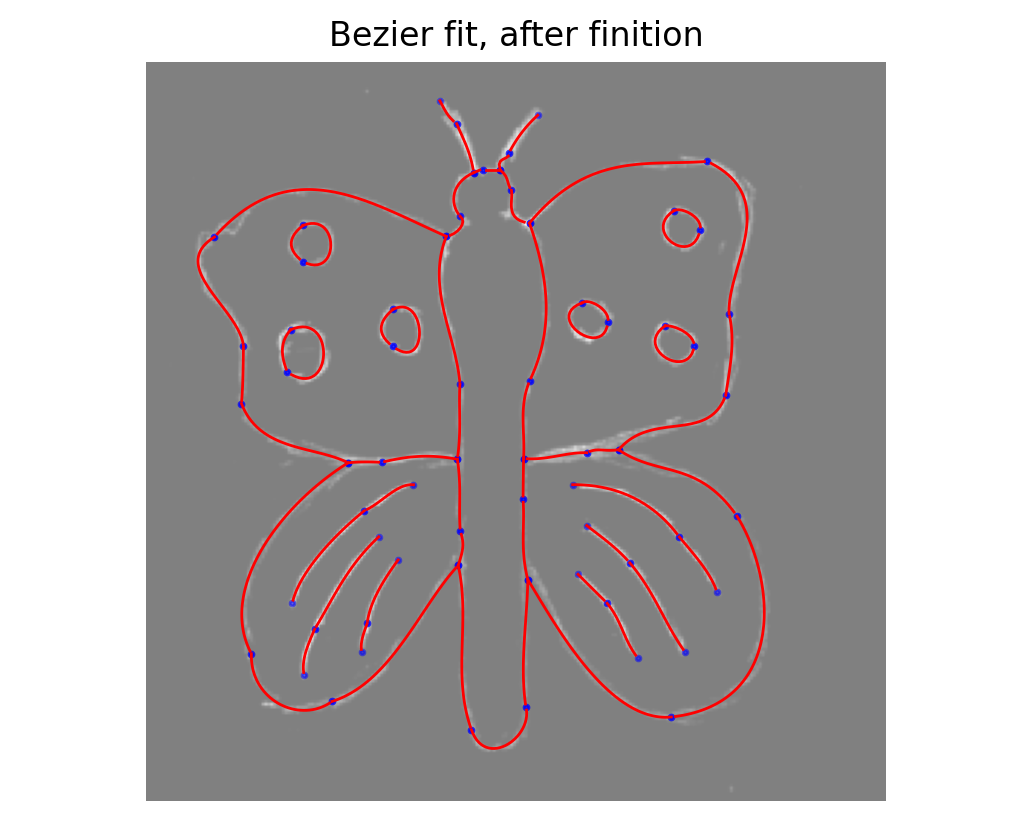

In [ ]:
hyper_1.finition()
visualize_hyper(hyper_1)
plt.imshow(img, alpha=0.5, cmap='gray')
_ax = plt.gca()
_ax.axis('off')
plt.title('Bezier fit, after finition')
plt.show()

## SVG export

In [ ]:
from IPython.display import SVG
from bez.app import generate_svg_str

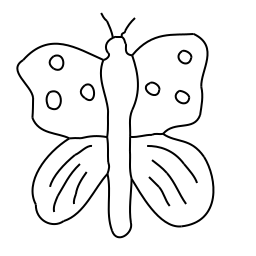

In [ ]:
out = generate_svg_str(img.shape, hyper_1, stroke_width=2)
SVG(out)

In [ ]:
from bez.app import show_example

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:28<00:00, 1624.14it/s]


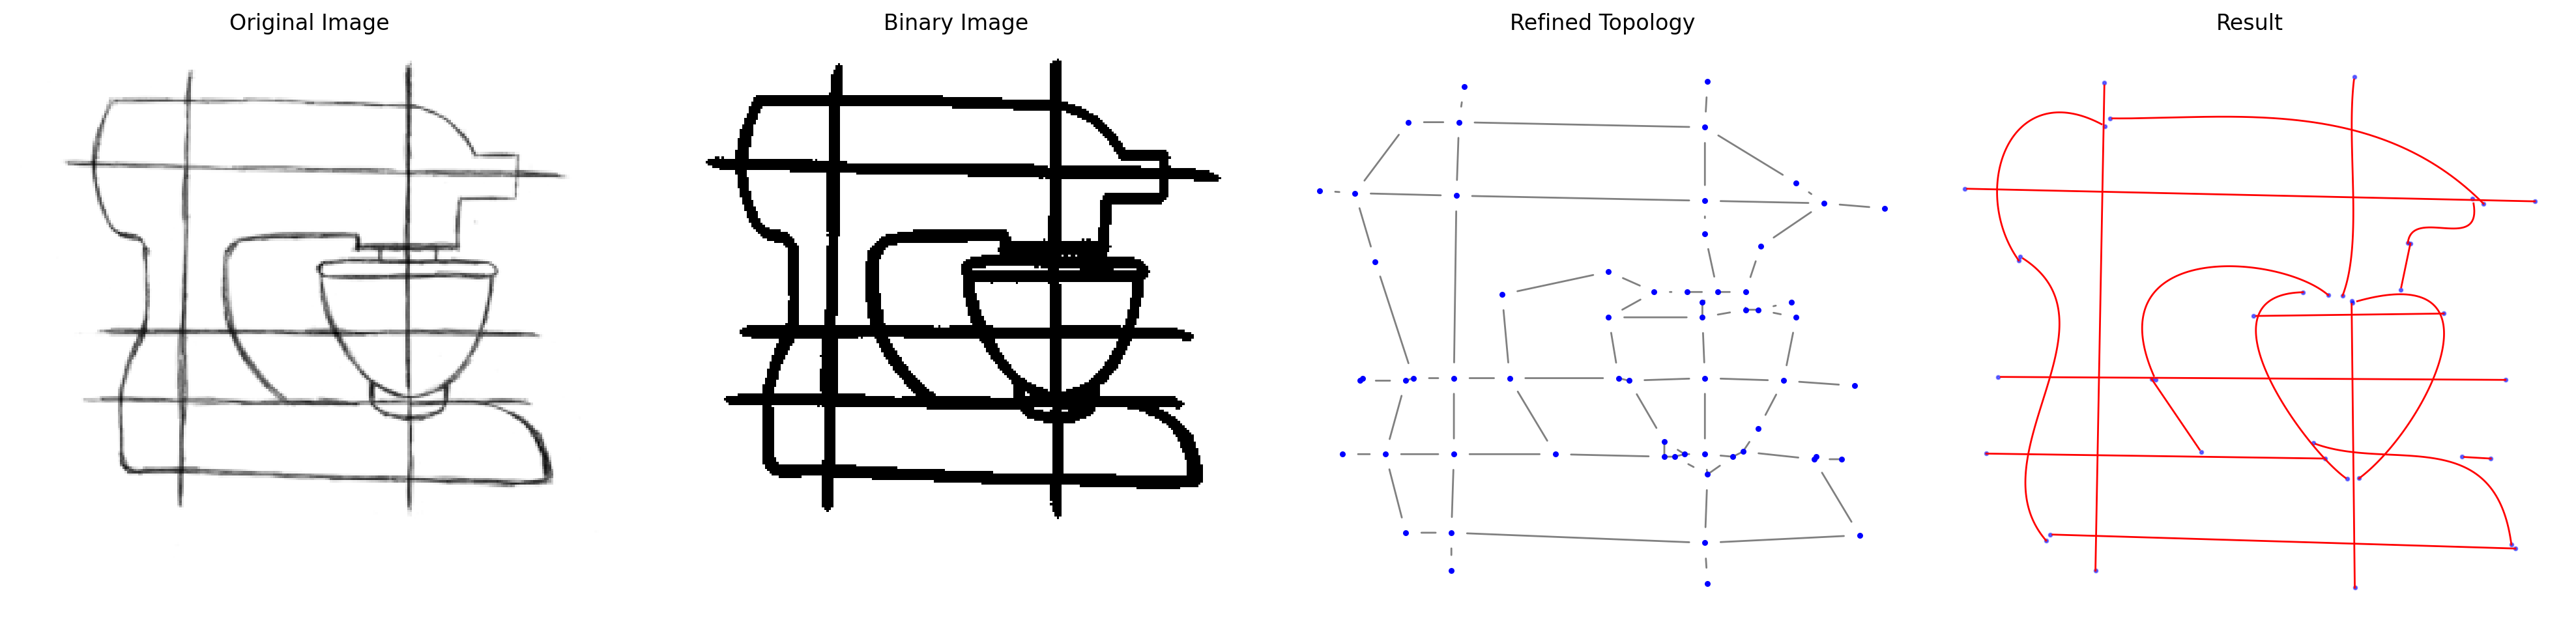

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_2/input.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:28<00:00, 1591.32it/s]


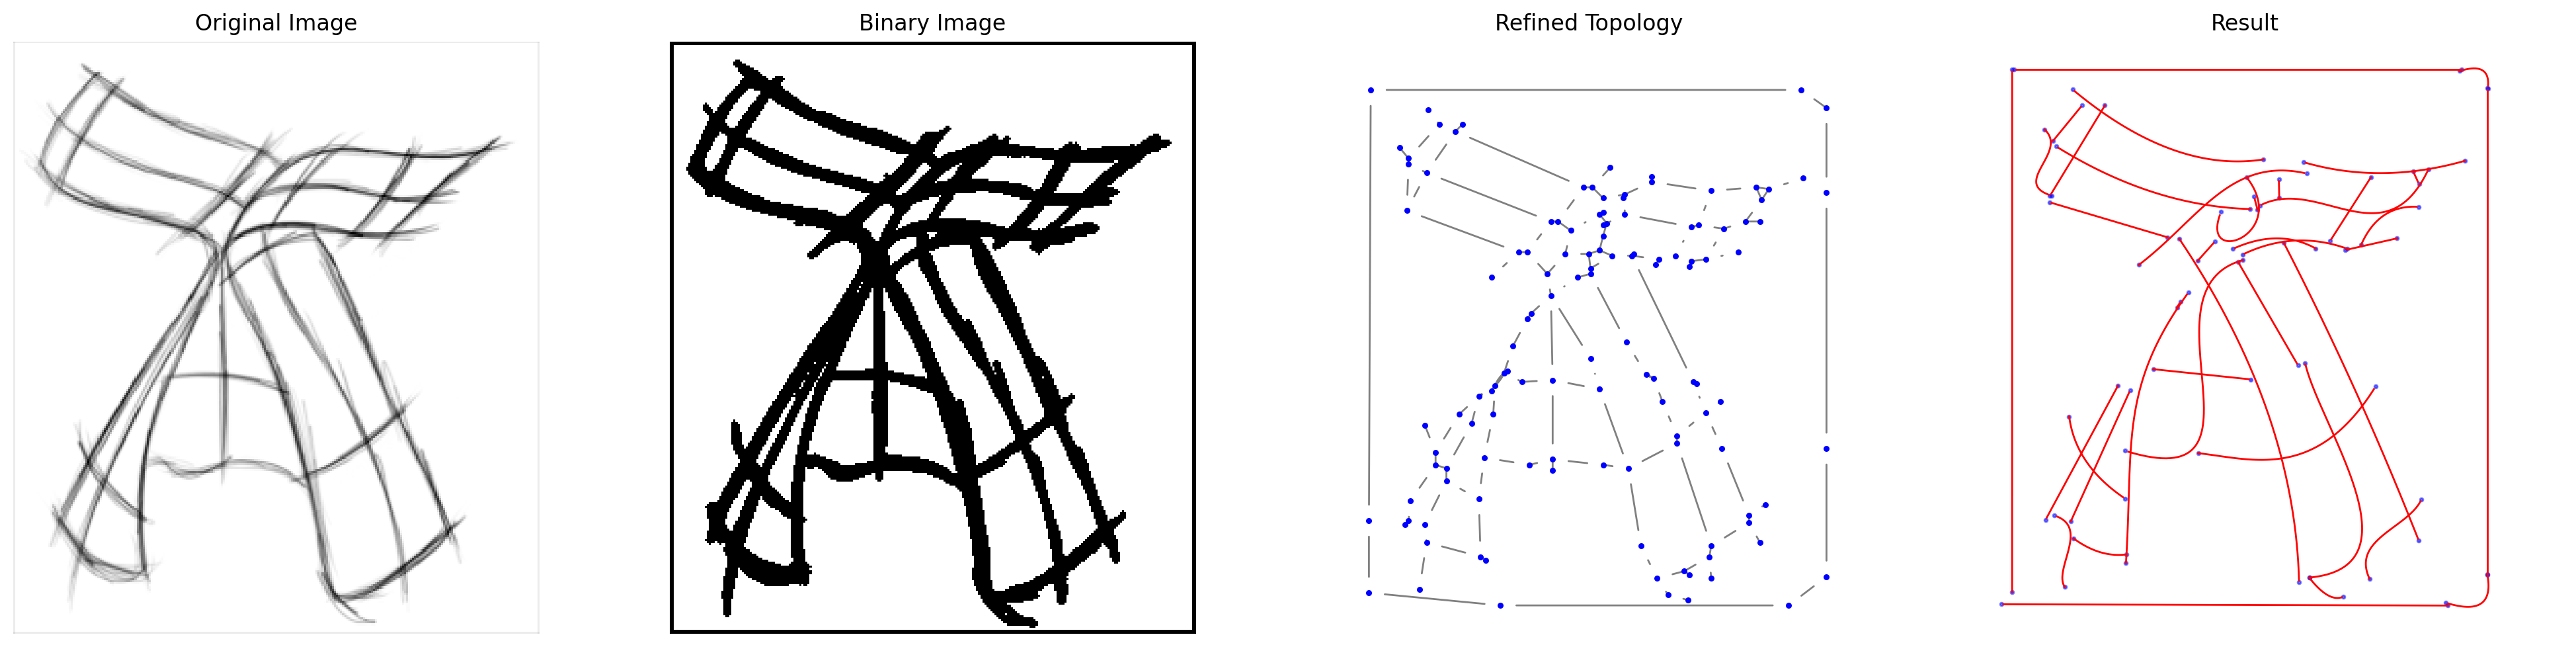

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_1/input.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:29<00:00, 1545.57it/s]


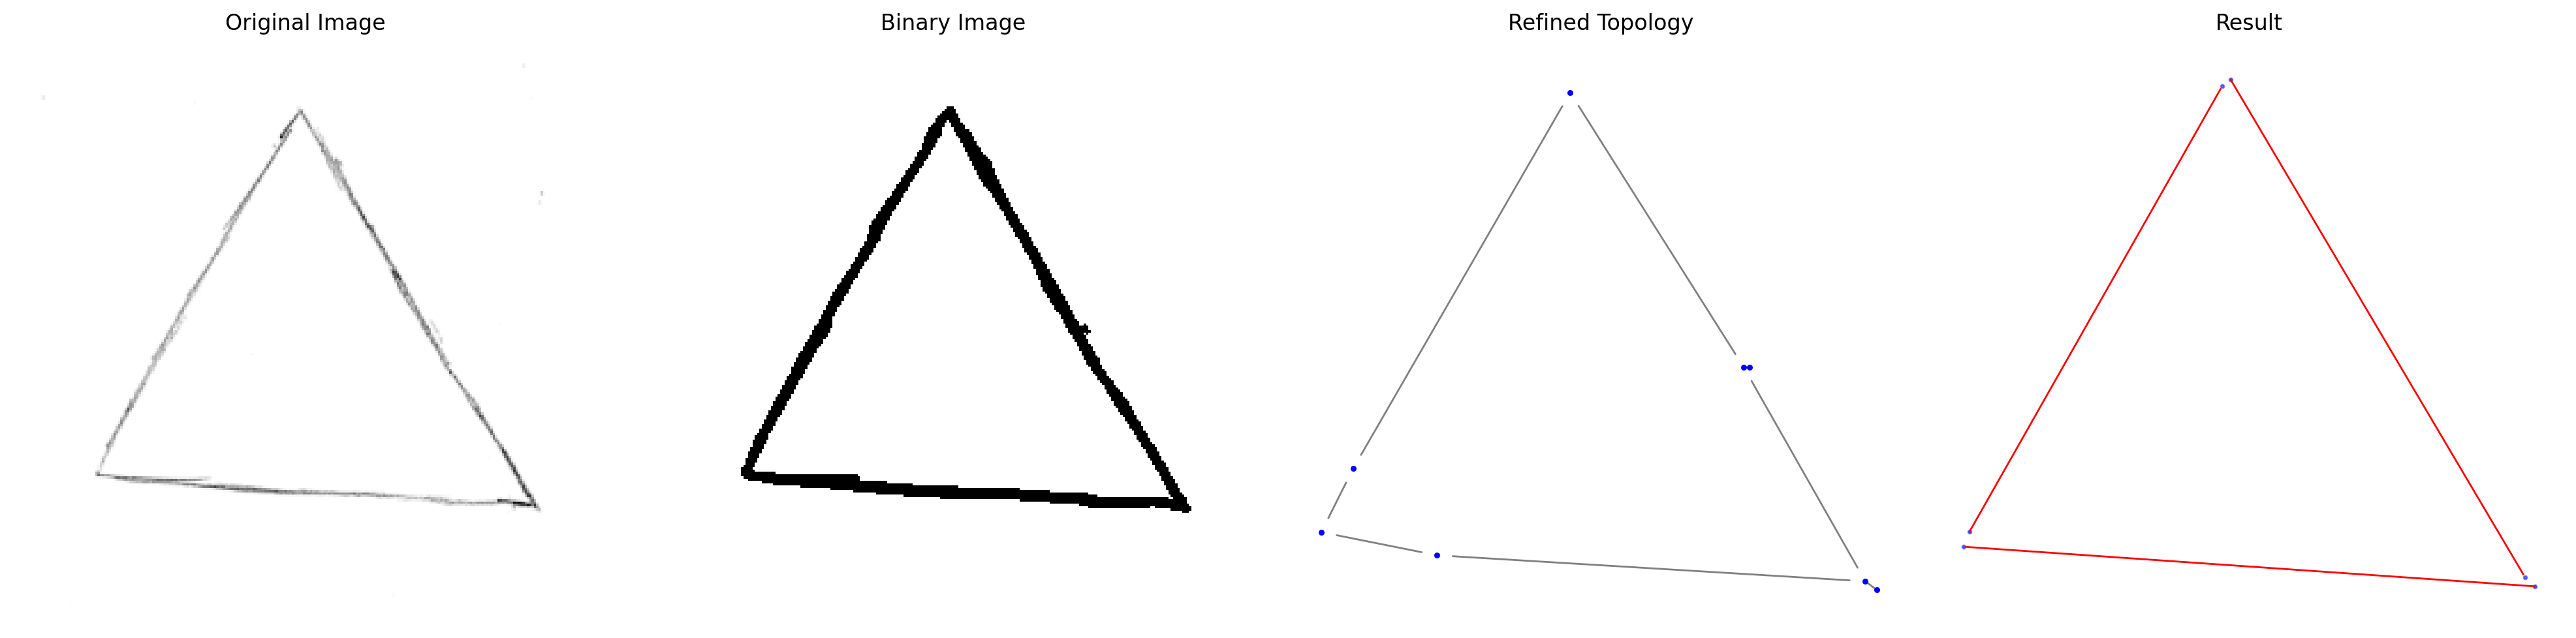

In [ ]:
show_example(ROOT_DIR / "data/sketches/triangle.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:27<00:00, 1665.66it/s]


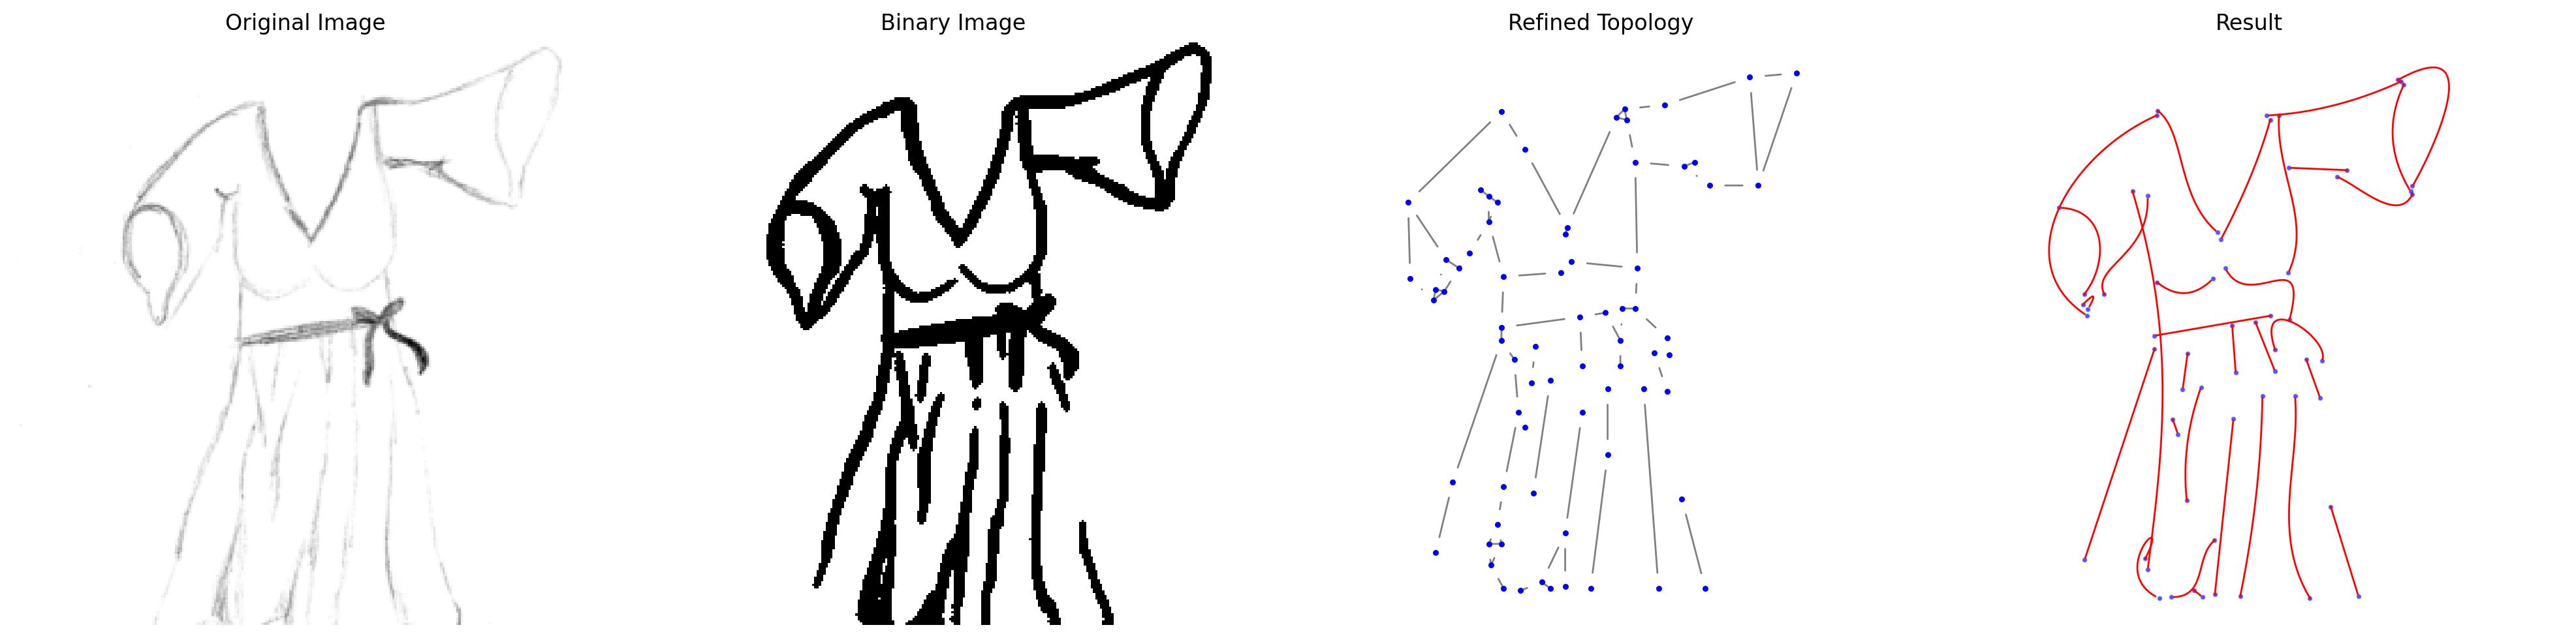

In [ ]:
show_example(ROOT_DIR / "data/sketches/dress.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:27<00:00, 1679.41it/s]


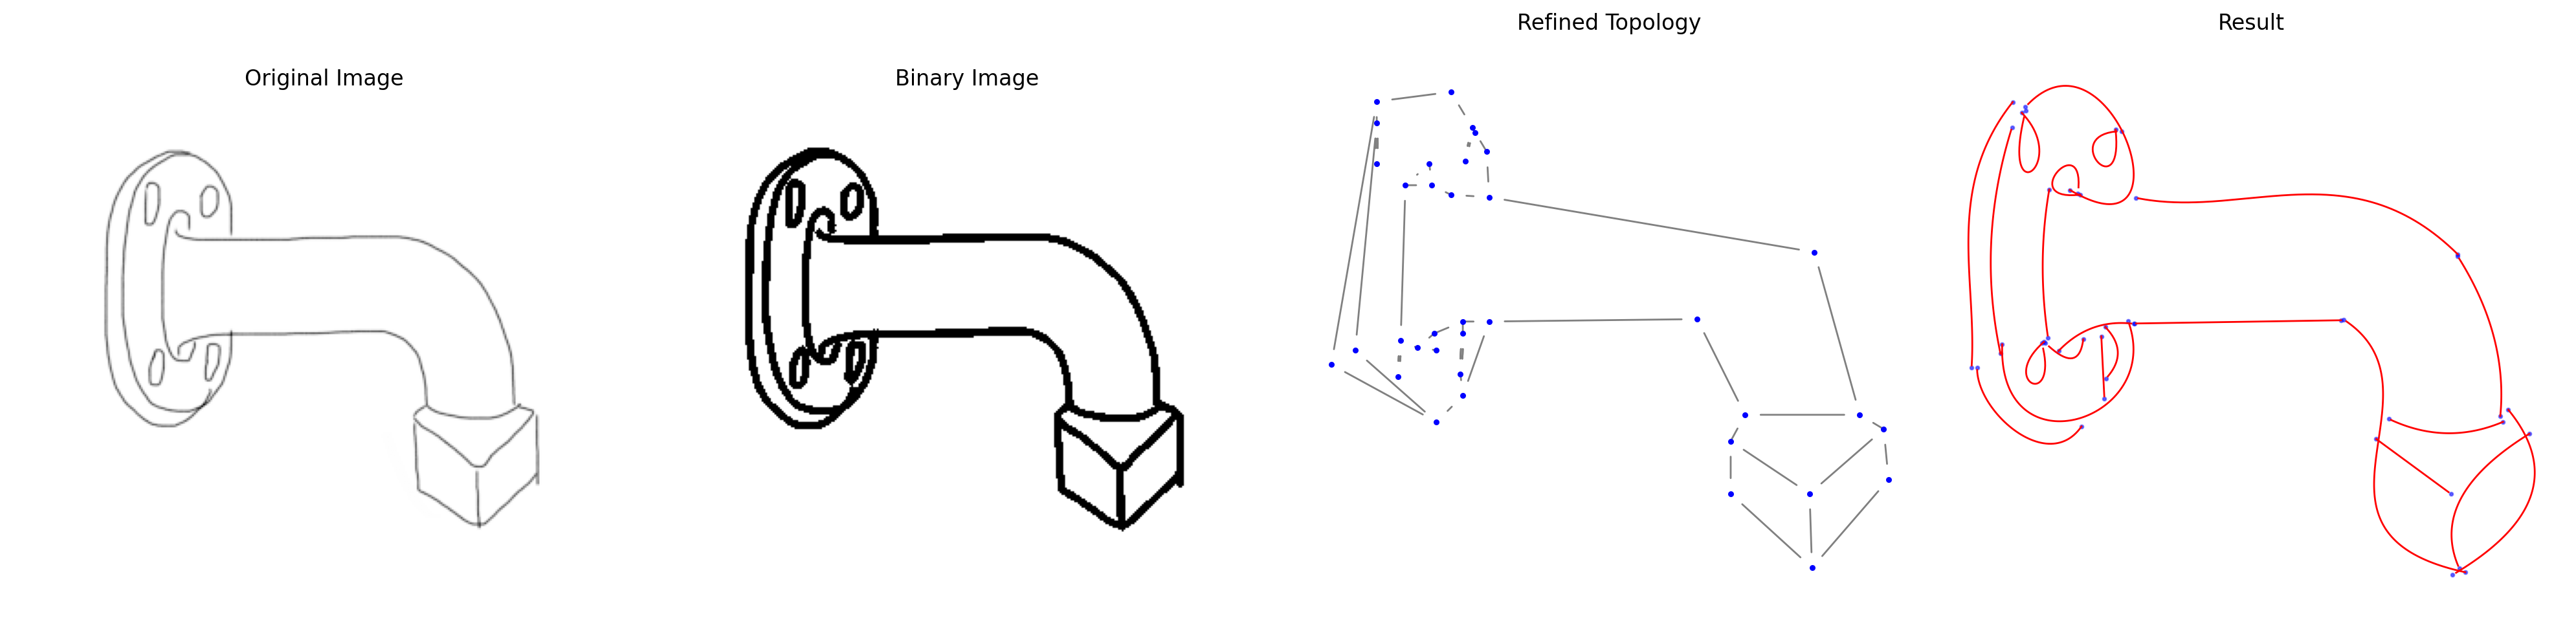

In [ ]:
show_example(ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/90 degree elbows/001_1.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:31<00:00, 1476.69it/s]


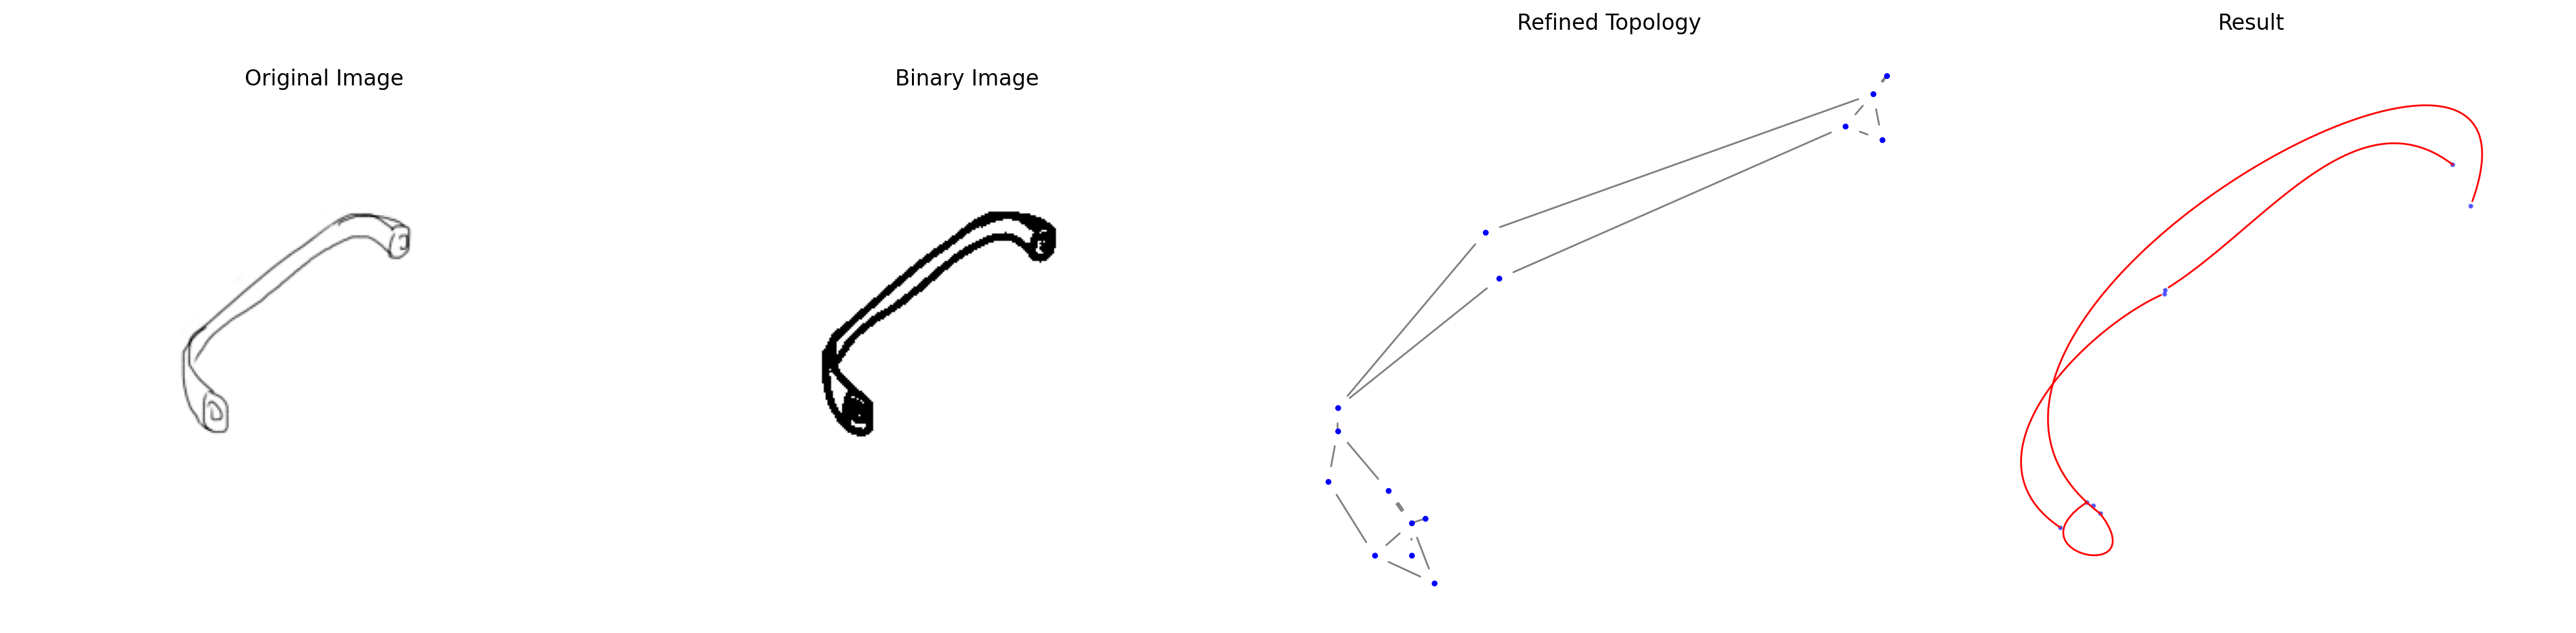

In [ ]:
show_example(ROOT_DIR / "data/CAD_dataset/Dataset_B/ESB_Sketches/U shaped parts/005_1.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:30<00:00, 1524.09it/s]


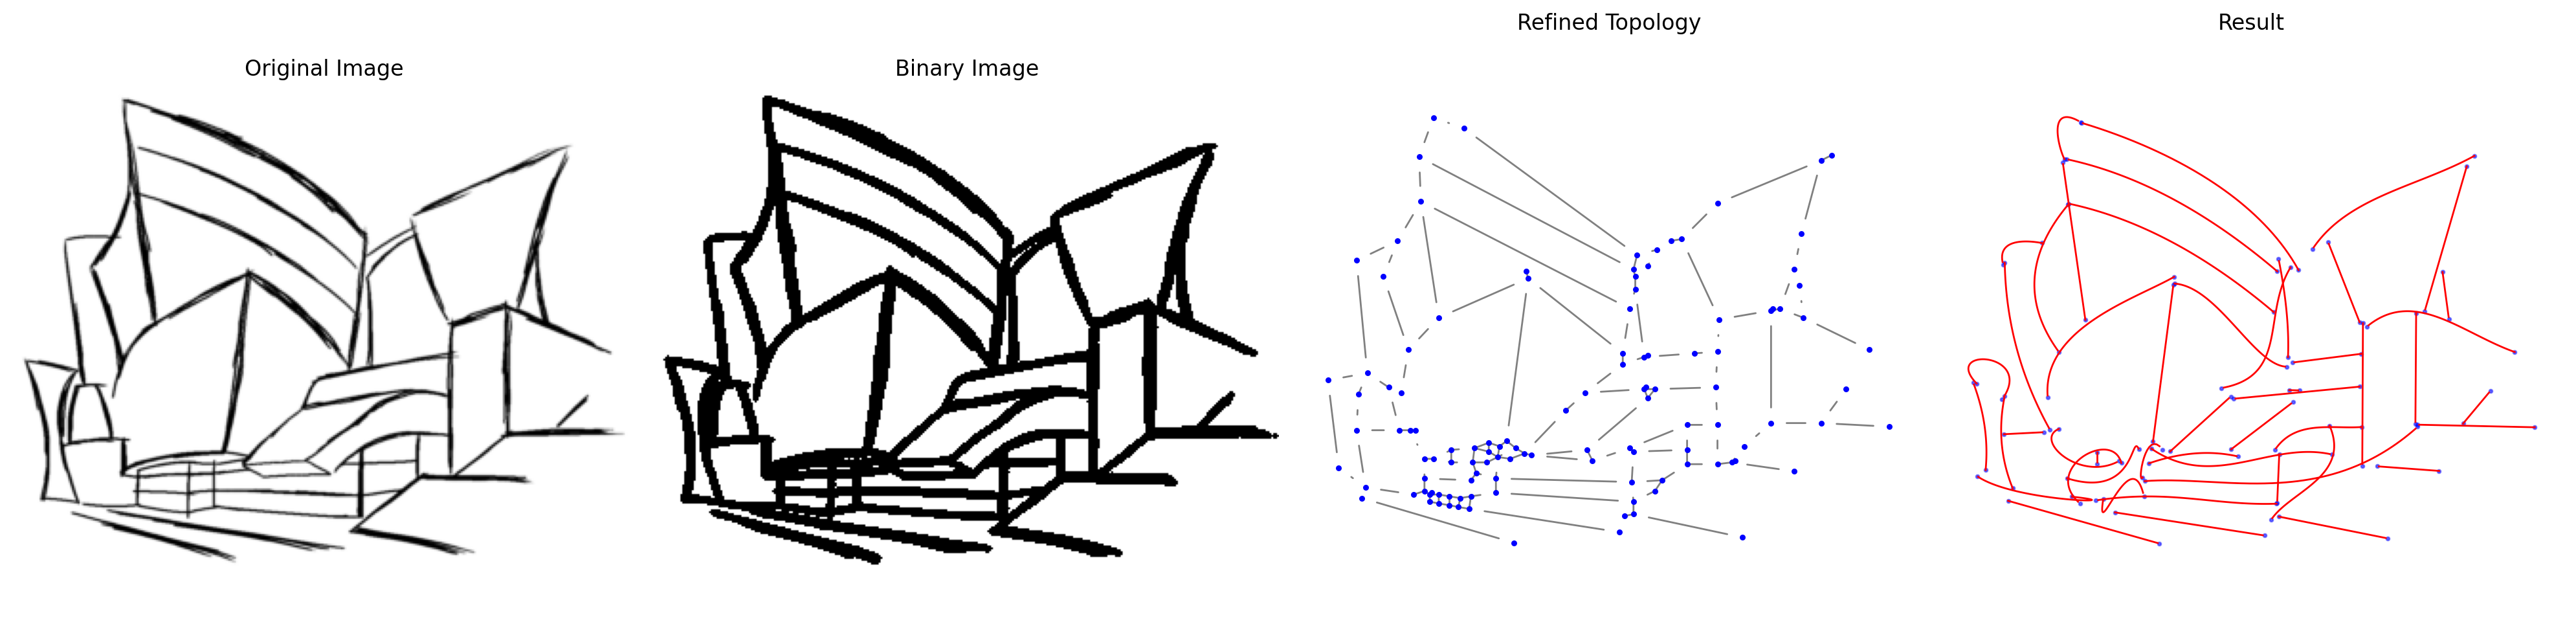

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_10/archi.png")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46050/46050 [00:27<00:00, 1657.05it/s]


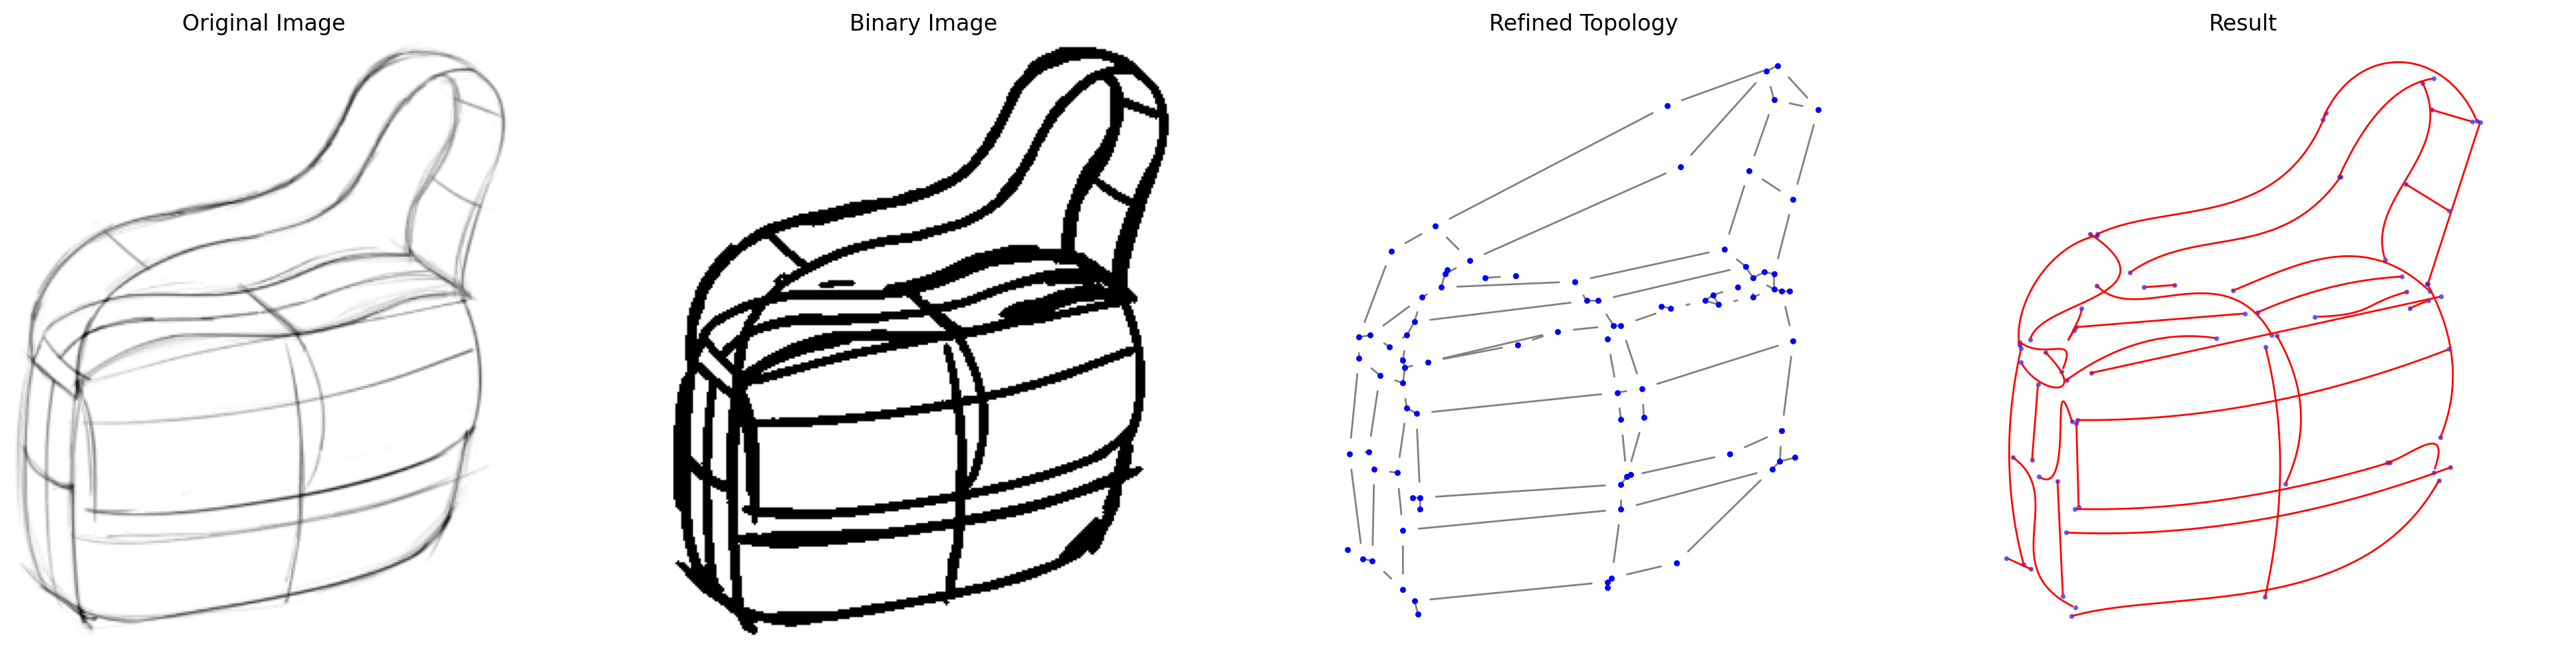

In [ ]:
show_example(ROOT_DIR / "data/original_paper/figure_14/bag/input.png")